# Importações

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

# Leitura das Imagens

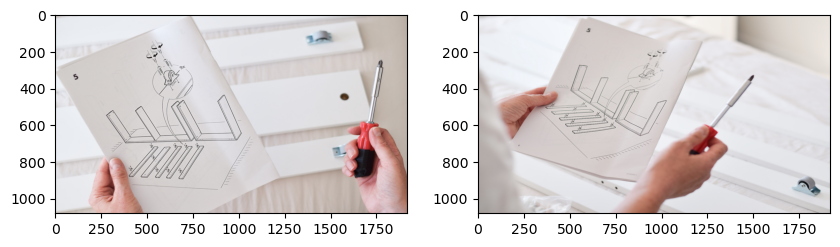

In [3]:
image_1 = cv.cvtColor(cv.imread(r'images\1.jpeg'), cv.COLOR_BGR2RGB)
image_2 = cv.cvtColor(cv.imread(r'images\2.jpeg'), cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,8))
axes[0].imshow(image_1)
axes[1].imshow(image_2)

# Extração de Caracteristicas

Vamos extrair caracteristicas ultizando ORB

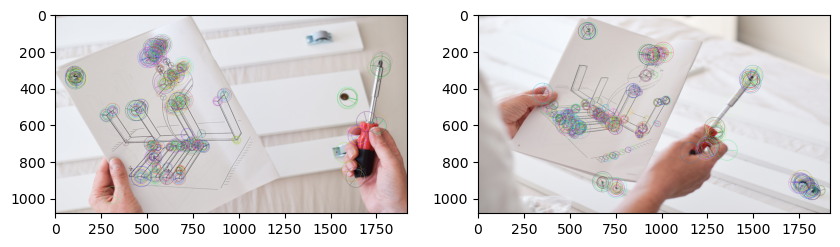

In [6]:
# Criando o detector de ORB.
orb = cv.ORB_create()

# detectando os keypoints.
kp1, des1 = orb.detectAndCompute(image_1, None)
kp2, des2 = orb.detectAndCompute(image_2, None)

# Visualização dos keypoints
image_1_kp = cv.drawKeypoints(image_1, kp1, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_2_kp = cv.drawKeypoints(image_2, kp2, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,6))
axes[0].imshow(image_1_kp)
axes[1].imshow(image_2_kp)

# Correspondência de caracteristicas

Vamos comparar todos os keypoints de ambas as imagens e encontrar correspodência entre essas imagens

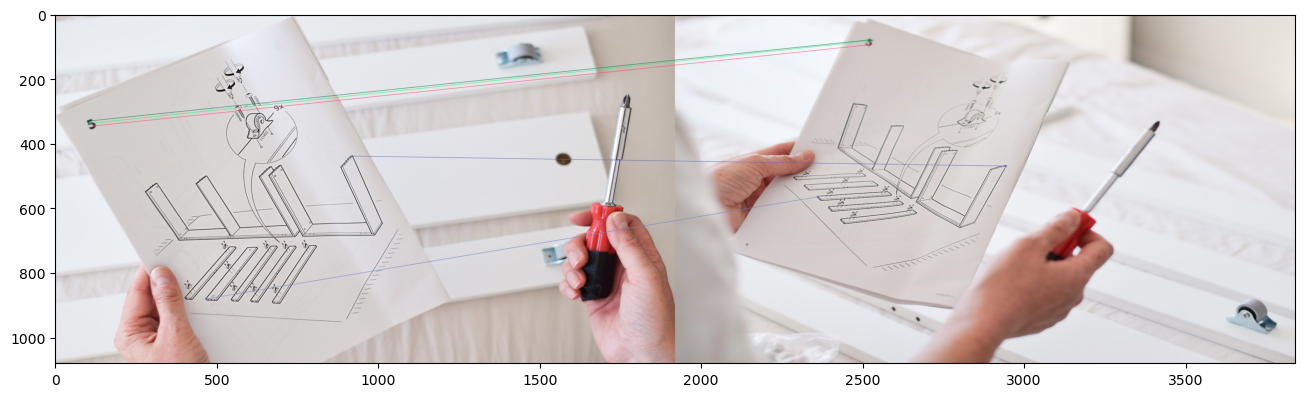

In [9]:
# Criando o matcher de força bruta
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)

# Realizando o matching entre os descritores
matches = bf.match(des1, des2)

# Ordenando  os matches com menor distância
matches = sorted(matches, key=lambda x:x.distance)

# Desenhar os 5 matches mais proximos
num = 5
image_matches = cv.drawMatches(image_1, kp1, image_2, kp2, matches[:num], None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(16,9))
plt.imshow(image_matches)